In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
data1 = pd.read_csv("data_csv.csv")
data2 = pd.read_csv("Toddler Autism dataset July 2018.csv")

In [6]:
print("Dataset 1 Preview")
display(data1.head())

print("Dataset 2 Preview")
display(data2.head())

Dataset 1 Preview


,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes


Dataset 2 Preview


,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [7]:
print("Dataset 1 columns : ",data1.columns)
print("Dataset 2 columns : ",data2.columns)

Dataset 1 columns :  Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='object')
Dataset 2 columns :  Index(['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
       'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits '],
      dtype='object')


## “We are using two autism screening datasets. One contains clinical features and the other contains QCHAT screening data.”

In [8]:
data1.shape

(1985, 28)

In [9]:
data2.shape

(1054, 19)

In [10]:
df1 = pd.concat([data1.iloc[:,1:11], data1.iloc[:,[12,22,23,24,25,26,27]]], axis=1)
df2 = pd.concat([data2.iloc[:,1:12], data2.iloc[:,13:]], axis=1)

In [11]:
print("Selected Columns from Dataset 1")
display(df1.head())

print("Selected Columns from Dataset 2")
display(df2.head())

Selected Columns from Dataset 1


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Age_Years,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,0,0,0,0,0,0,1,1,0,1,2,F,middle eastern,Yes,No,Family Member,No
1,1,1,0,0,0,1,1,0,0,0,3,M,White European,Yes,No,Family Member,Yes
2,1,0,0,0,0,0,1,1,0,1,3,M,Middle Eastern,Yes,No,Family Member,Yes
3,1,1,1,1,1,1,1,1,1,1,2,M,Hispanic,No,No,Family Member,Yes
4,1,1,0,1,1,1,1,1,1,1,2,F,White European,No,No,Family Member,Yes


Selected Columns from Dataset 2


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,0,0,0,0,0,0,1,1,0,1,28,f,middle eastern,yes,no,family member,No
1,1,1,0,0,0,1,1,0,0,0,36,m,White European,yes,no,family member,Yes
2,1,0,0,0,0,0,1,1,0,1,36,m,middle eastern,yes,no,family member,Yes
3,1,1,1,1,1,1,1,1,1,1,24,m,Hispanic,no,no,family member,Yes
4,1,1,0,1,1,1,1,1,1,1,20,f,White European,no,yes,family member,Yes


## “We selected only relevant features such as behavioral questions (A1–A10), demographic details, and ASD label.”

In [12]:
df2['Age_Mons'] = (df2['Age_Mons']/12).astype(int)
df2.columns = df1.columns

In [13]:
data_fin = pd.concat([df2, df1], axis=0)


print("Before Encoding")
display(data_fin.head())

print("Unique Values")
for col in ['Sex', 'Jaundice', 'Family_mem_with_ASD']:
    print(col, data_fin[col].unique())



data_fin['Sex'] = data_fin['Sex'].replace({'f':'F','m':'M'})
data_fin['Jaundice'] = data_fin['Jaundice'].replace({'yes':'Yes','no':'No'})
data_fin['Family_mem_with_ASD'] = data_fin['Family_mem_with_ASD'].replace({'yes':'Yes','no':'No'})

Before Encoding


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Age_Years,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,0,0,0,0,0,0,1,1,0,1,2,f,middle eastern,yes,no,family member,No
1,1,1,0,0,0,1,1,0,0,0,3,m,White European,yes,no,family member,Yes
2,1,0,0,0,0,0,1,1,0,1,3,m,middle eastern,yes,no,family member,Yes
3,1,1,1,1,1,1,1,1,1,1,2,m,Hispanic,no,no,family member,Yes
4,1,1,0,1,1,1,1,1,1,1,1,f,White European,no,yes,family member,Yes


Unique Values
Sex ['f' 'm' 'F' 'M']
Jaundice ['yes' 'no' 'Yes' 'No']
Family_mem_with_ASD ['no' 'yes' 'No' 'Yes']


In [14]:
data_fin.fillna(data_fin.mode().iloc[0], inplace=True)


In [ ]:
print("Merged Dataset")
display(data_fin.head())

print("Shape:", data_fin.shape)

Merged Dataset


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Age_Years,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,0,0,0,0,0,0,1,1,0,1,2,F,middle eastern,Yes,No,family member,No
1,1,1,0,0,0,1,1,0,0,0,3,M,White European,Yes,No,family member,Yes
2,1,0,0,0,0,0,1,1,0,1,3,M,middle eastern,Yes,No,family member,Yes
3,1,1,1,1,1,1,1,1,1,1,2,M,Hispanic,No,No,family member,Yes
4,1,1,0,1,1,1,1,1,1,1,1,F,White European,No,Yes,family member,Yes


Shape: (3039, 17)


In [16]:
print(data_fin['ASD_traits'].value_counts())

ASD_traits
Yes    1802
No     1237
Name: count, dtype: int64


In [17]:
data_fin.columns

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
       'A10_Autism_Spectrum_Quotient', 'Age_Years', 'Sex', 'Ethnicity',
       'Jaundice', 'Family_mem_with_ASD', 'Who_completed_the_test',
       'ASD_traits'],
      dtype='object')

## “Both datasets are merged to increase data size and improve model performance.”

In [18]:
le = LabelEncoder()

In [19]:
for col in data_fin.select_dtypes('object').columns:
    data_fin[col] = le.fit_transform(data_fin[col])
X = data_fin.drop(columns=["ASD_traits"])
y = data_fin["ASD_traits"]

In [20]:
print("After Encoding")
display(data_fin.head())

After Encoding


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Age_Years,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,0,0,0,0,0,0,1,1,0,1,2,0,14,1,0,7,0
1,1,1,0,0,0,1,1,0,0,0,3,1,11,1,0,7,1
2,1,0,0,0,0,0,1,1,0,1,3,1,14,1,0,7,1
3,1,1,1,1,1,1,1,1,1,1,2,1,2,0,0,7,1
4,1,1,0,1,1,1,1,1,1,1,1,0,11,0,1,7,1


## “Categorical values like Yes/No and Male/Female are converted into numeric form for machine learning.”

In [21]:
pip install seaborn --trusted-host pypi.org --trusted-host files.pythonhosted.org

You should consider upgrading via the 'c:\Users\BAPS\Desktop\Autism\Autism_GEO\venv\Scripts\python.exe -m pip install --upgrade pip' command.


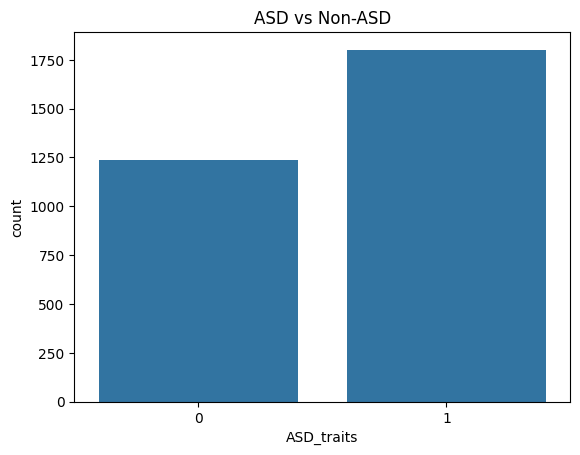

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='ASD_traits', data=data_fin)
plt.title("ASD vs Non-ASD")
plt.show()

In [23]:
pd.crosstab(data_fin['Sex'], data_fin['ASD_traits'])

ASD_traits,0,1
Sex,,
0,552,305
1,685,1497


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.23, random_state=45, stratify=y)

In [25]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2340, 16)
Test shape: (699, 16)


## “We split the data into training and testing to evaluate model performance.”

In [26]:
sc = MinMaxScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [27]:
print("Sample scaled data:")
print(X_train_scaled[:5])

Sample scaled data:
[[1.         0.         0.         1.         1.         1.
  1.         1.         1.         0.         0.94117647 1.
  0.25       1.         1.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.76470588 1.
  0.25       0.         0.         0.28571429]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.76470588 1.
  0.6875     1.         0.         0.28571429]
 [1.         1.         1.         0.         1.         1.
  0.         1.         1.         0.         0.11764706 1.
  0.25       1.         1.         0.        ]
 [1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         0.76470588 1.
  0.375      1.         0.         0.28571429]]


## “We normalize data using MinMaxScaler to improve model performance.”

In [28]:
params = {
    'max_depth': [5,10,20],
    'min_samples_leaf': [5,10,20],
    'n_estimators': [50,100,200]
}

grid = GridSearchCV(
    rf, params, cv=4, scoring="accuracy", n_jobs=-1, verbose=1
)

grid.fit(X_train_scaled, y_train)

Fitting 4 folds for each of 27 candidates, totalling 108 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [29]:
rf_best = grid.best_estimator_

p_tab = rf_best.predict_proba(X_test_scaled)[:,1]

print("Tabular Accuracy:",accuracy_score(y_test, (p_tab>0.5).astype(int)))

Tabular Accuracy: 0.9484978540772532


In [1]:
results = pd.DataFrame(grid.cv_results_)
display(results[['params','mean_test_score']])

NameError: name 'pd' is not defined

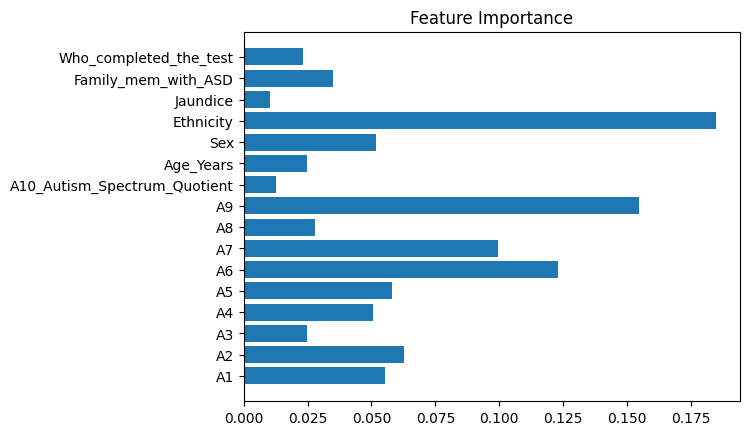

In [ ]:
import matplotlib.pyplot as plt

importances = rf_best.feature_importances_
feat_names = X.columns

plt.barh(feat_names, importances)
plt.title("Feature Importance")
plt.show()

## “We tested multiple parameter combinations to find the best model.”

In [32]:
import pickle

In [33]:
with open("autism_model.pkl", "wb") as f:
    pickle.dump(rf_best, f)

In [34]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(sc, f)

In [35]:
with open("features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [ ]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

: 